## Data set up

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, precision_recall_curve, roc_curve, classification_report, confusion_matrix
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay

In [13]:
df = pd.read_csv('clean_data_eda.csv')
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,0
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,0
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,0
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,0
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,0


In [14]:
target = "Revenue"
y = df[target].astype(int)
X = df.drop(columns=[target])

# Identify columns
categorical_cols = ["Month", "VisitorType", "Weekend"]
# Treat these integer-coded identifiers as categorical for logistic regression
id_like_cols = ["OperatingSystems", "Browser", "Region", "TrafficType"]

# Numeric behavior features
numeric_cols = [c for c in X.columns if c not in categorical_cols + id_like_cols]

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## Basic model

In [16]:
preprocess_base = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols + id_like_cols),
    ],
    remainder="drop"
)

xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', n_jobs=-1)

pipe = Pipeline([
    ("preprocess", preprocess_base),
    ("model", xgb_model)
])

## Tune parameters

In [17]:
# Perform GridSearchCV for hyperparameter tuning
param_grid = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [3, 4, 5],
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__subsample': [0.8, 0.9, 1.0],
    'model__colsample_bytree': [0.8, 0.9, 1.0],
    'model__gamma': [0, 0.1, 0.2],
    'model__reg_alpha': [0, 0.1, 0.5],
    'model__reg_lambda': [1, 1.1, 1.2]
}

grid_search = GridSearchCV(pipe, param_grid, cv=3, verbose=1, n_jobs=-1, scoring='roc_auc')
grid_search.fit(X_train, y_train)

# Best parameters and model
best_model = grid_search.best_estimator_
best_params = grid_search.best_params_

print(f"Best Parameters: {best_params}")

Fitting 3 folds for each of 6561 candidates, totalling 19683 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [21:21:32] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best Parameters: {'model__colsample_bytree': 0.9, 'model__gamma': 0, 'model__learning_rate': 0.01, 'model__max_depth': 5, 'model__n_estimators': 300, 'model__reg_alpha': 0.5, 'model__reg_lambda': 1.2, 'model__subsample': 0.8}


## Model evaluation

In [18]:
def eval_model(pipe, X_train, y_train, X_test, y_test, name="model"):
    t0 = time.time()
    pipe.fit(X_train, y_train)
    train_time = time.time() - t0

    proba = pipe.predict_proba(X_test)[:, 1]
    roc = roc_auc_score(y_test, proba)
    ap = average_precision_score(y_test, proba)

    print(f"\n=== {name} ===")
    print(f"Train time: {train_time:.3f} sec")
    print(f"ROC-AUC:    {roc:.4f}")
    print(f"PR-AUC(AP): {ap:.4f}")

    # Optional: threshold 0.5 report
    preds = (proba >= 0.5).astype(int)
    print("\nClassification report @0.5:")
    print(classification_report(y_test, preds, digits=4))

    return {"name": name, "train_time": train_time, "roc_auc": roc, "pr_auc": ap}

In [19]:
eval_model(best_model, X_train, y_train, X_test, y_test, name="Best XGBoost Model")

# Precision-Recall Curve and optimal threshold
proba = best_model.predict_proba(X_test)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_test, proba)

# F1 calculation
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)

# Find best threshold
best_idx = f1_scores.argmax()
best_threshold = thresholds[best_idx]

best_threshold, f1_scores[best_idx]

# Generate predictions based on the optimal threshold
optimal_preds = (proba >= best_threshold).astype(int)

print("Optimal threshold:", round(best_threshold, 4))
print("\nClassification report @ optimal threshold:")
print(classification_report(y_test, optimal_preds, digits=4))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [21:21:33] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



=== Best XGBoost Model ===
Train time: 0.758 sec
ROC-AUC:    0.9359
PR-AUC(AP): 0.7567

Classification report @0.5:
              precision    recall  f1-score   support

           0     0.9293    0.9582    0.9436      2059
           1     0.7296    0.6073    0.6629       382

    accuracy                         0.9033      2441
   macro avg     0.8295    0.7828    0.8032      2441
weighted avg     0.8981    0.9033    0.8996      2441

Optimal threshold: 0.373

Classification report @ optimal threshold:
              precision    recall  f1-score   support

           0     0.9463    0.9417    0.9440      2059
           1     0.6939    0.7120    0.7028       382

    accuracy                         0.9058      2441
   macro avg     0.8201    0.8269    0.8234      2441
weighted avg     0.9068    0.9058    0.9063      2441



Confusion Matrix:
[[1973   86]
 [ 150  232]]


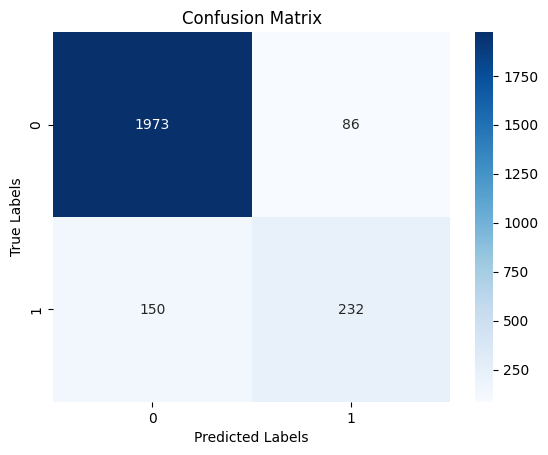

In [23]:

# Make predictions on the test set
y_pred = best_model.predict(X_test)

# Calculate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Print the confusion matrix
print("Confusion Matrix:")
print(cm)

# Visualize the confusion matrix using seaborn
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

## Log transformation?? Balance classes?? Other adjustments?


## Feature importance

In [20]:
# Feature importances (XGBoost)
importances = best_model.named_steps["model"].feature_importances_

# Get processed feature names
preprocess = best_model.named_steps["preprocess"]
ohe = preprocess.named_transformers_["cat"]
cat_feature_names = ohe.get_feature_names_out(categorical_cols + id_like_cols)
all_feature_names = np.concatenate([numeric_cols, cat_feature_names])

# Create a DataFrame for feature importances
coef_df = pd.DataFrame({
    "feature": all_feature_names,
    "importance": importances
})

# Sort by importance
coef_df_sorted = coef_df.reindex(
    coef_df["importance"].sort_values(ascending=False).index
)

# Show top 10 features
coef_df_sorted.head(10)

,feature,importance
8,PageValues,0.377620
17,Month_Nov,0.069325
16,Month_May,0.032874
22,VisitorType_Returning_Visitor,0.027864
15,Month_Mar,0.027513
6,BounceRates,0.026749
5,ProductRelated_Duration,0.019111
0,Administrative,0.017805
7,ExitRates,0.017653
19,Month_Sep,0.016837


## Summary

XGBoost is appropriate to use because there is a large number observations to train the data on and because there is a mix of categorical and numerical variables. It is a tree based algorithm that uses gradient boosting to create more accurate approximations of the data. Trees are grown sequentially, where each successive tree learns and boosts from the previous tree.

Based on the results, the optimal parameters for an XGBoost model for our data are:

```
Best Parameters: {'model__colsample_bytree': 0.9, 'model__gamma': 0, 'model__learning_rate': 0.01, 'model__max_depth': 5,
'model__n_estimators': 300, 'model__reg_alpha': 0.5, 'model__reg_lambda': 1.2, 'model__subsample': 0.8}
```

This optimal model results in the following metrics:  
```
=== Best XGBoost Model ===
Train time: 0.758 sec
ROC-AUC:    0.9359
PR-AUC(AP): 0.7567

Optimal threshold: 0.373

Classification report @ optimal threshold:
              precision    recall  f1-score   support

           0     0.9463    0.9417    0.9440      2059
           1     0.6939    0.7120    0.7028       382

    accuracy                         0.9058      2441
   macro avg     0.8201    0.8269    0.8234      2441
weighted avg     0.9068    0.9058    0.9063      2441
```

Due to class imbalance, where there are fewer instances of people purchasing something that the model can be trained on, the model is less accurate at predicting instances of someone purchasing something than it is at predicting instances of someone not purchasing something.